In [114]:
print("Thinking...")
import warnings
import pandas as pd                    # For reading CSV files into tables
import numpy as np                     # For numerical calculations
print("Thinking...")
from scipy import signal               # For the Welch PSD / spectral analysis
from matplotlib import pyplot as plt   # For creating plots
import os
print("Thinking...")
import tkinter as tk
from tkinter import filedialog
from matplotlib import gridspec
from matplotlib.colors import LogNorm

warnings.simplefilter('ignore')

Thinking...
Thinking...
Thinking...


Thinking...
Thinking...
Thinking...

File metadata:
  Job: 40T_Compare
  Sample Rate: 1651.6129032258063
  Start Time: Mon Jul 27 2026 14:21:42 GMT-0700 (Pacific Daylight Time)


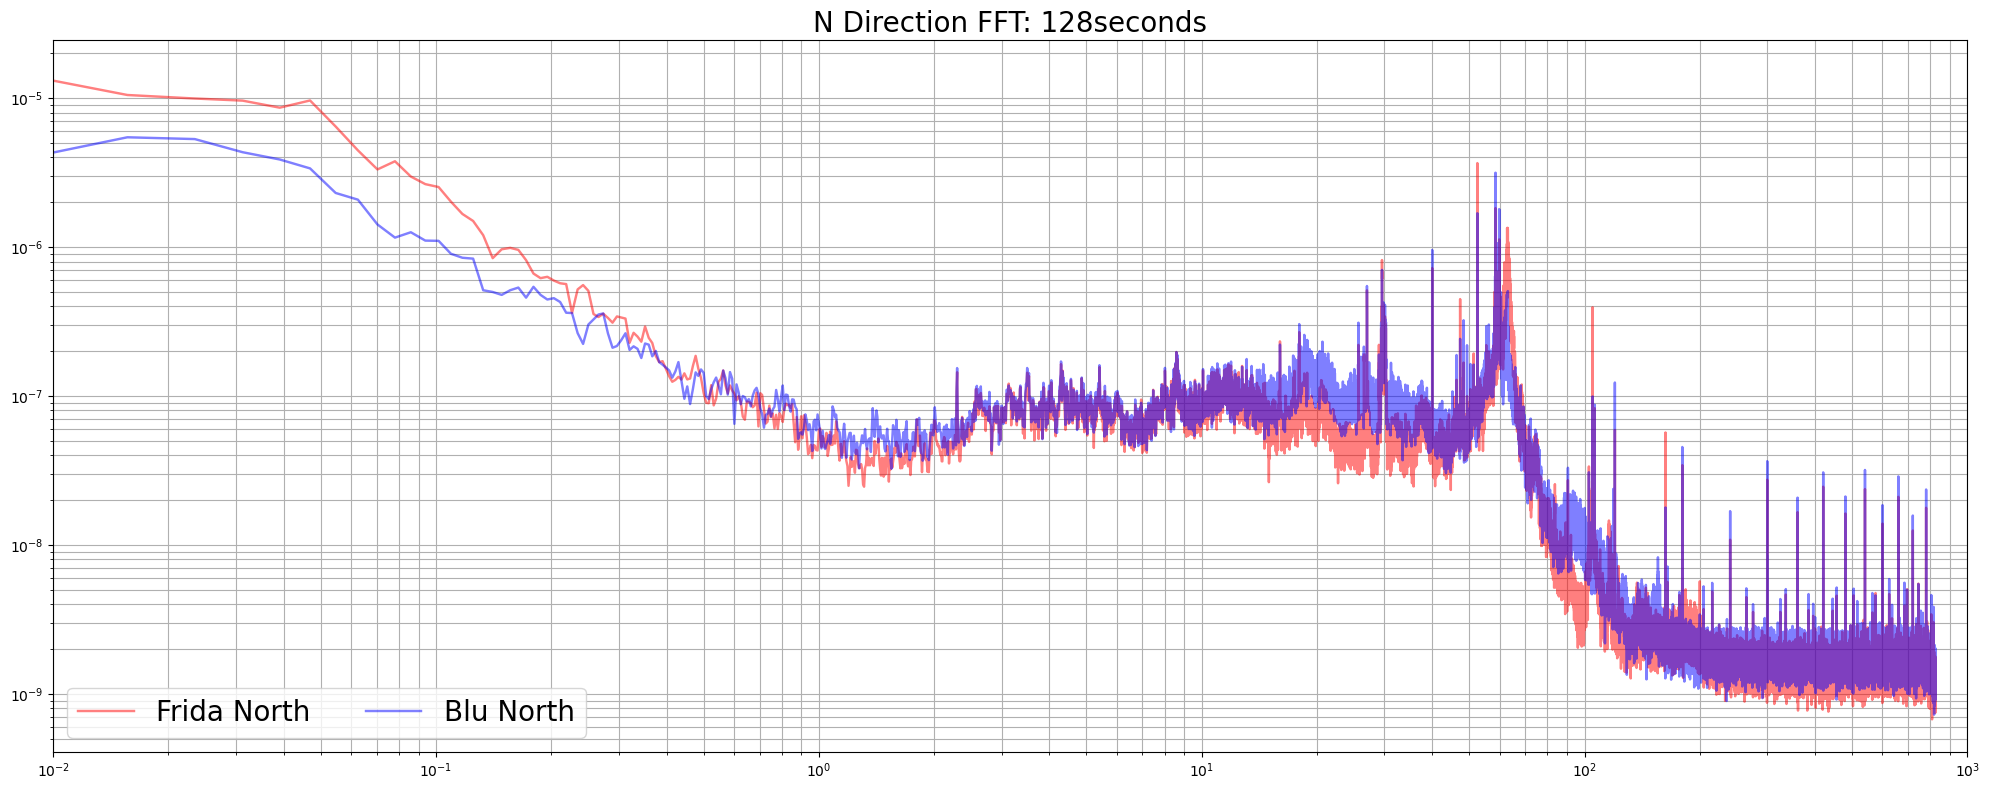

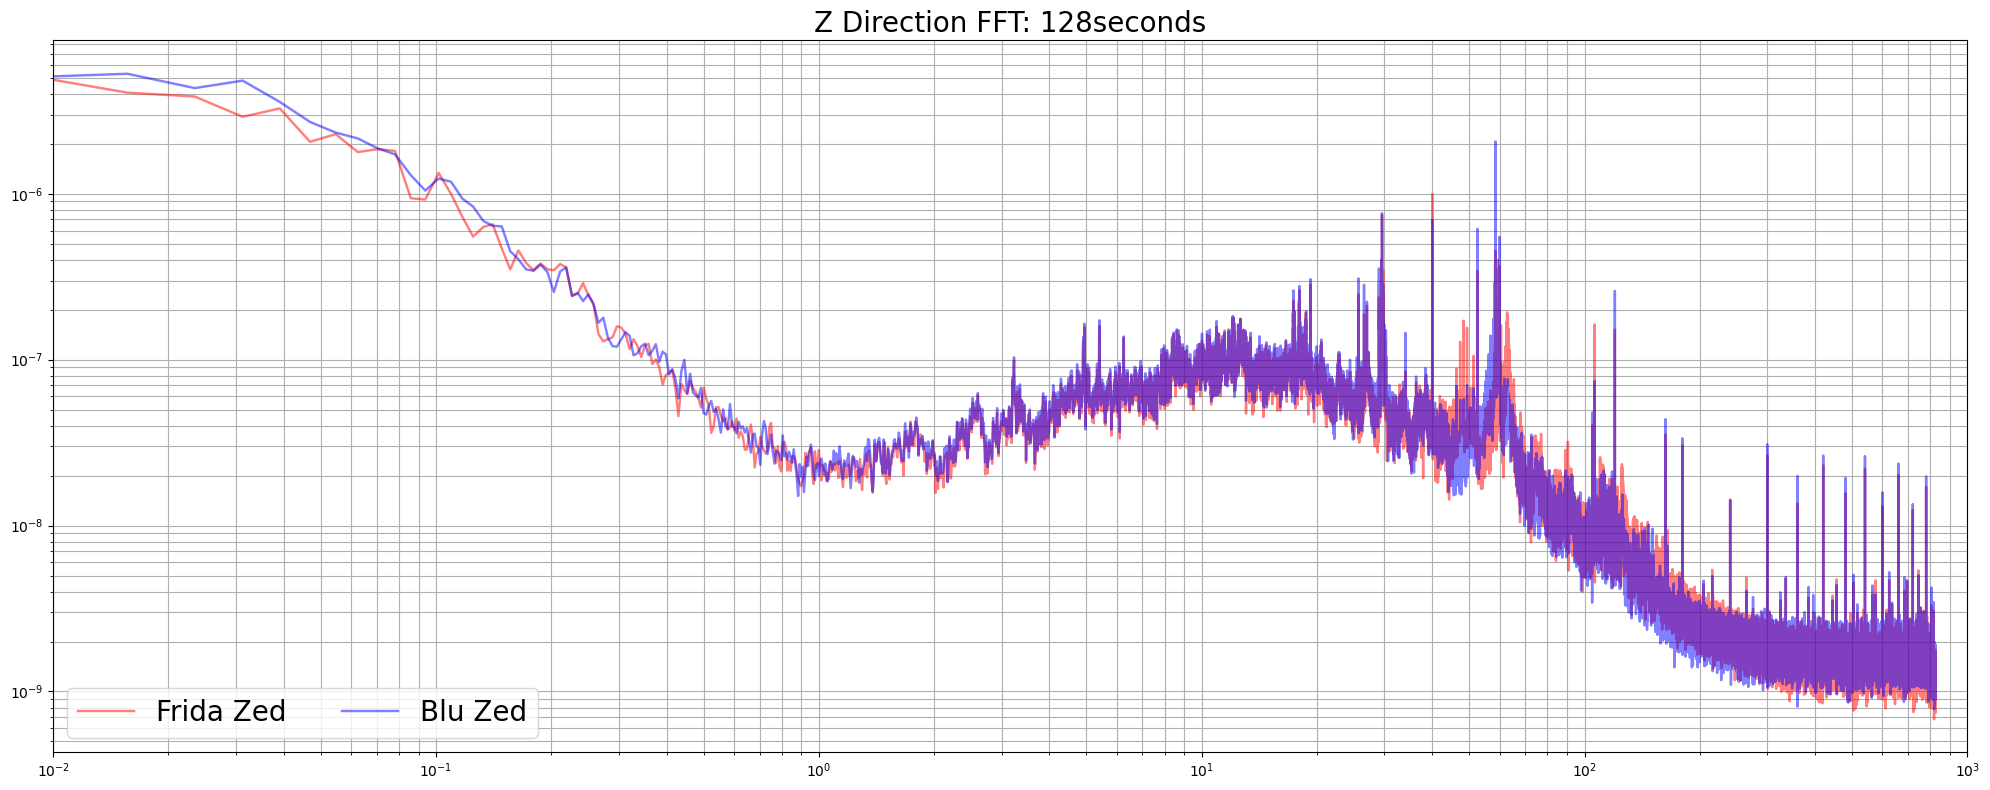

In [110]:
### --- Read data and do FFT --- ###

data_file_path = r"C:\Users\shrey\Downloads\40T_compare_2026-07-27_1.38m_Fglass.csv"


Frida_First = True     ## Is Frida on channels 1 and 2
pre_amps=False

### --- FFT Params --- ###
fft_window_s = 128
overlap = 50



metadata = {}
with open(data_file_path, 'r') as f:
    for _ in range(5):
        line = f.readline().strip()
        if ':' in line:
            key, value = line.split(':', 1)
            metadata[key.strip()] = value.strip()

print("\nFile metadata:")
for key, value in metadata.items():
    print(f"  {key}: {value}")

sample_rate = float(metadata["Sample Rate"])


## -------------- Read the seismic data columns --------------- ##

raw_data = pd.read_csv(data_file_path, skiprows=5, delimiter=',')


if Frida_First == True:
    raw_data.columns = ["Sample", "Time (s)", 
                        "F N", "F Z", 
                        "B N", "B Z", 
                        "blank"]
else:
    raw_data.columns = ["Sample", "Time (s)", 
                        "B N", "B Z", 
                        "F N", "F Z", 
                        "blank"]


## --- Apply calibration factor (Volts → meters per second) --- ##
if pre_amps:
    calibration = (0.0125e-1) / 21
else:
    calibration = 0.0125e-1

F_N   = raw_data["F N"] * calibration   # 
F_Z   = raw_data["F Z"] * calibration   # 
B_N   = raw_data["B N"]  * calibration   # 
B_Z   = raw_data["B Z"]  * calibration   # 
time  = raw_data["Time (s)"]



## --- FFT Function --- ##
def welch_asd(data, sr):
        """
        Run Welch's method on `data` sampled at `sr` Hz.
        Returns (frequencies, amplitude_spectral_density).
        """
        data = np.asarray(data)   # Ensure it's a plain numpy array

        frequencies, power = signal.welch(
            data,
            sr,
            window   = 'hamming',
            nperseg  = int(sr * fft_window_s),                  ## nperseg:  number of samples per FFT window
            noverlap = int(round(sr * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
        )
        
        # ASD = square root of PSD
        return frequencies, np.sqrt(power)




## --- Do FFT --- ##
freq1, F_Z_asd = welch_asd(F_Z, sample_rate)
freq2, B_Z_asd = welch_asd(B_Z, sample_rate)

freq1, F_N_asd = welch_asd(F_N, sample_rate)
freq2, B_N_asd = welch_asd(B_N, sample_rate)


plt.figure(figsize=(20, 8))
plt.title("N Direction FFT: "+str(fft_window_s)+"seconds",fontsize = 20)
plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-2,1e3)
plt.plot(freq1, F_N_asd, linewidth  = 1.75,
                 alpha      = 0.5,
                 label      = "Frida North",
                 color      = "red")
plt.plot(freq2, B_N_asd, linewidth  = 1.75,
                 alpha      = 0.5,
                 label      = "Blu North",
                 color      = "blue")
plt.legend(loc = 'lower left', fontsize = 20, ncol = 2)
plt.grid(True, which = 'both', ls = '-')
plt.tight_layout()
#plt.savefig("test_" + str(ch) +".pdf")
plt.show()

plt.figure(figsize=(20, 8))
plt.title("Z Direction FFT: "+str(fft_window_s)+"seconds",fontsize = 20)
plt.yscale('log')
plt.xscale('log')
plt.xlim(1e-2,1e3)
plt.plot(freq1, F_Z_asd, linewidth  = 1.75,
                 alpha      = 0.5,
                 label      = "Frida Zed",
                 color      = "red")
plt.plot(freq2, B_Z_asd, linewidth  = 1.75,
                 alpha      = 0.5,
                 label      = "Blu Zed",
                 color      = "blue")
plt.legend(loc = 'lower left', fontsize = 20, ncol = 2)
plt.grid(True, which = 'both', ls = '-')
plt.tight_layout()
#plt.savefig("test_" + str(ch) +".pdf")
plt.show()



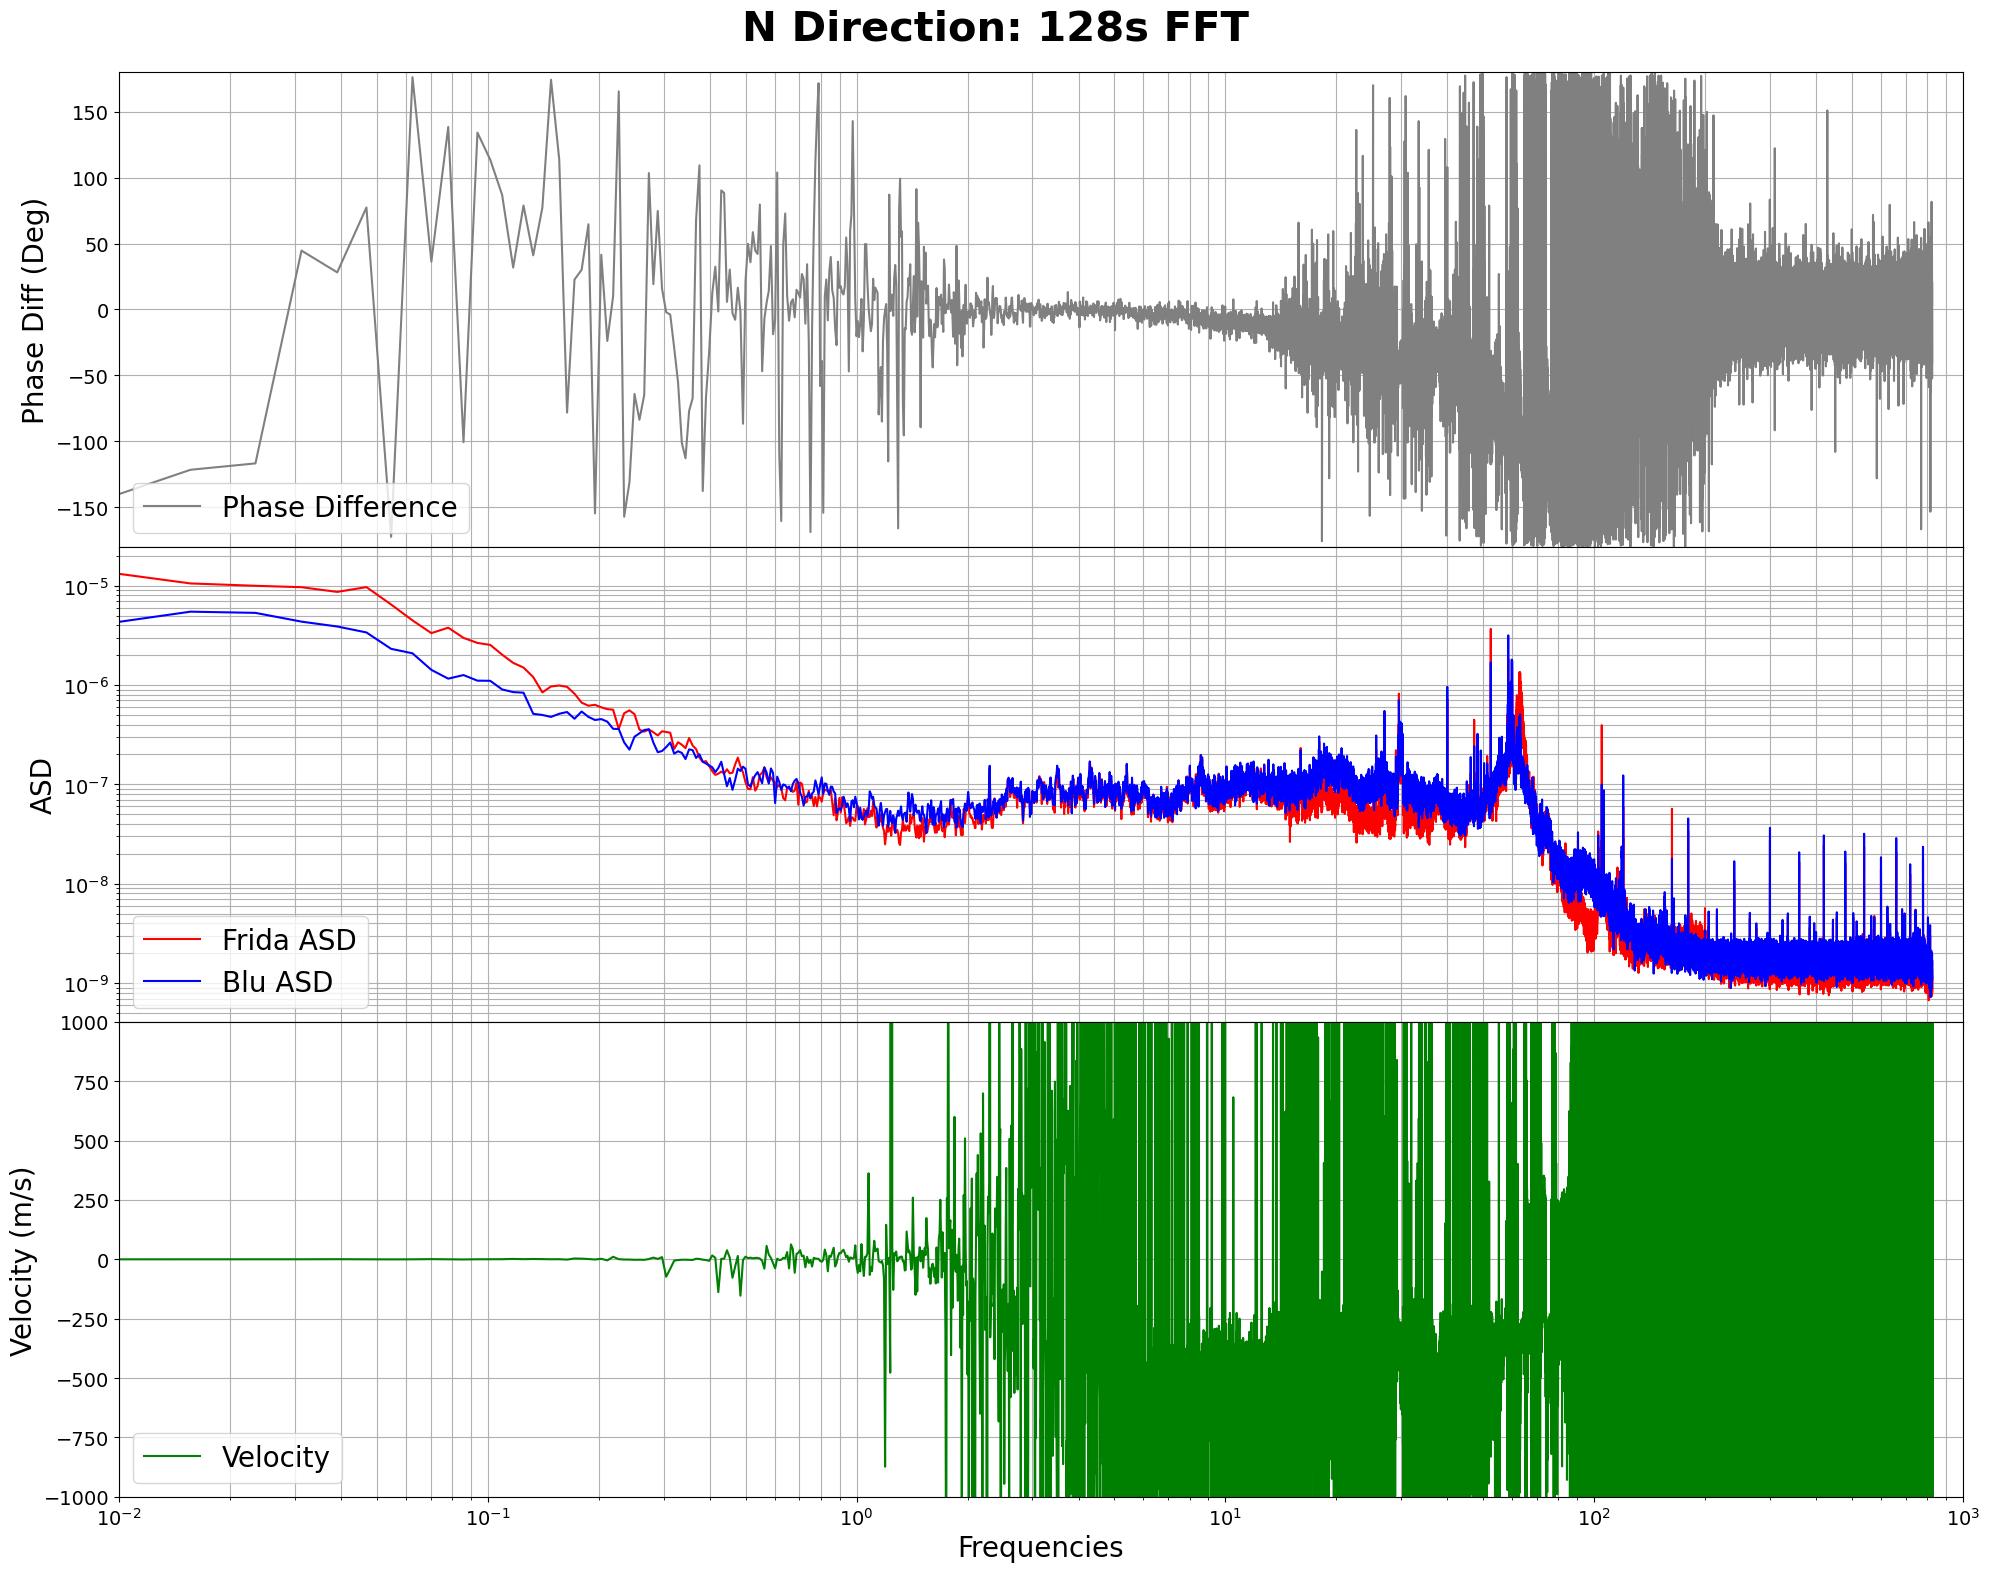

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import csd

distance = 1.38 #meters


frequencies, power_density = csd(B_N, F_N, fs=sample_rate,
                                window   = 'hamming',
                                nperseg  = int(sample_rate * fft_window_s),                  ## nperseg:  number of samples per FFT window
                                noverlap = int(round(sample_rate * (overlap * 0.01) ) )      ## noverlap: number of samples shared between adjacent windows
                                   )

phase_spectrum = np.angle(power_density)

phase_spectrum_deg = np.rad2deg(phase_spectrum)

vel = (frequencies * distance * 360) / phase_spectrum_deg




### --- Plot ---- ###
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(20, 16))
axs[0].set_xlim(1e-2,1e3)
axs[0].set_xscale('log')


axs[0].plot(frequencies, phase_spectrum_deg, label='Phase Difference',color='gray')
axs[0].set_ylabel('Phase Diff (Deg)',fontsize=20)
axs[0].set_ylim(-180,180)
axs[0].legend(fontsize=20,loc = 'lower left')

axs[1].plot(freq1, F_N_asd, label="Frida ASD", color='red')
axs[1].plot(freq2, B_N_asd, label="Blu ASD", color = 'blue')
axs[1].set_ylabel('ASD',fontsize=20)
axs[1].set_yscale('log')
axs[1].legend(fontsize=20,loc = 'lower left')

axs[2].plot(frequencies, vel, label='Velocity',color='green')
axs[2].set_ylabel('Velocity (m/s)',fontsize=20)
axs[2].set_ylim(-1000,1000)
axs[2].set_xlabel('Frequencies',fontsize=20)  # Label only the bottom plot
axs[2].legend(fontsize=20,loc = 'lower left')


for ax in axs:
    ax.grid(True, which='both', ls='-')
    ax.tick_params(axis='both', which='both', labelsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.suptitle("N Direction: "+str(fft_window_s)+"s FFT",fontsize = 30,fontweight='bold', y=0.98)
fig.subplots_adjust(hspace=0)
plt.show()

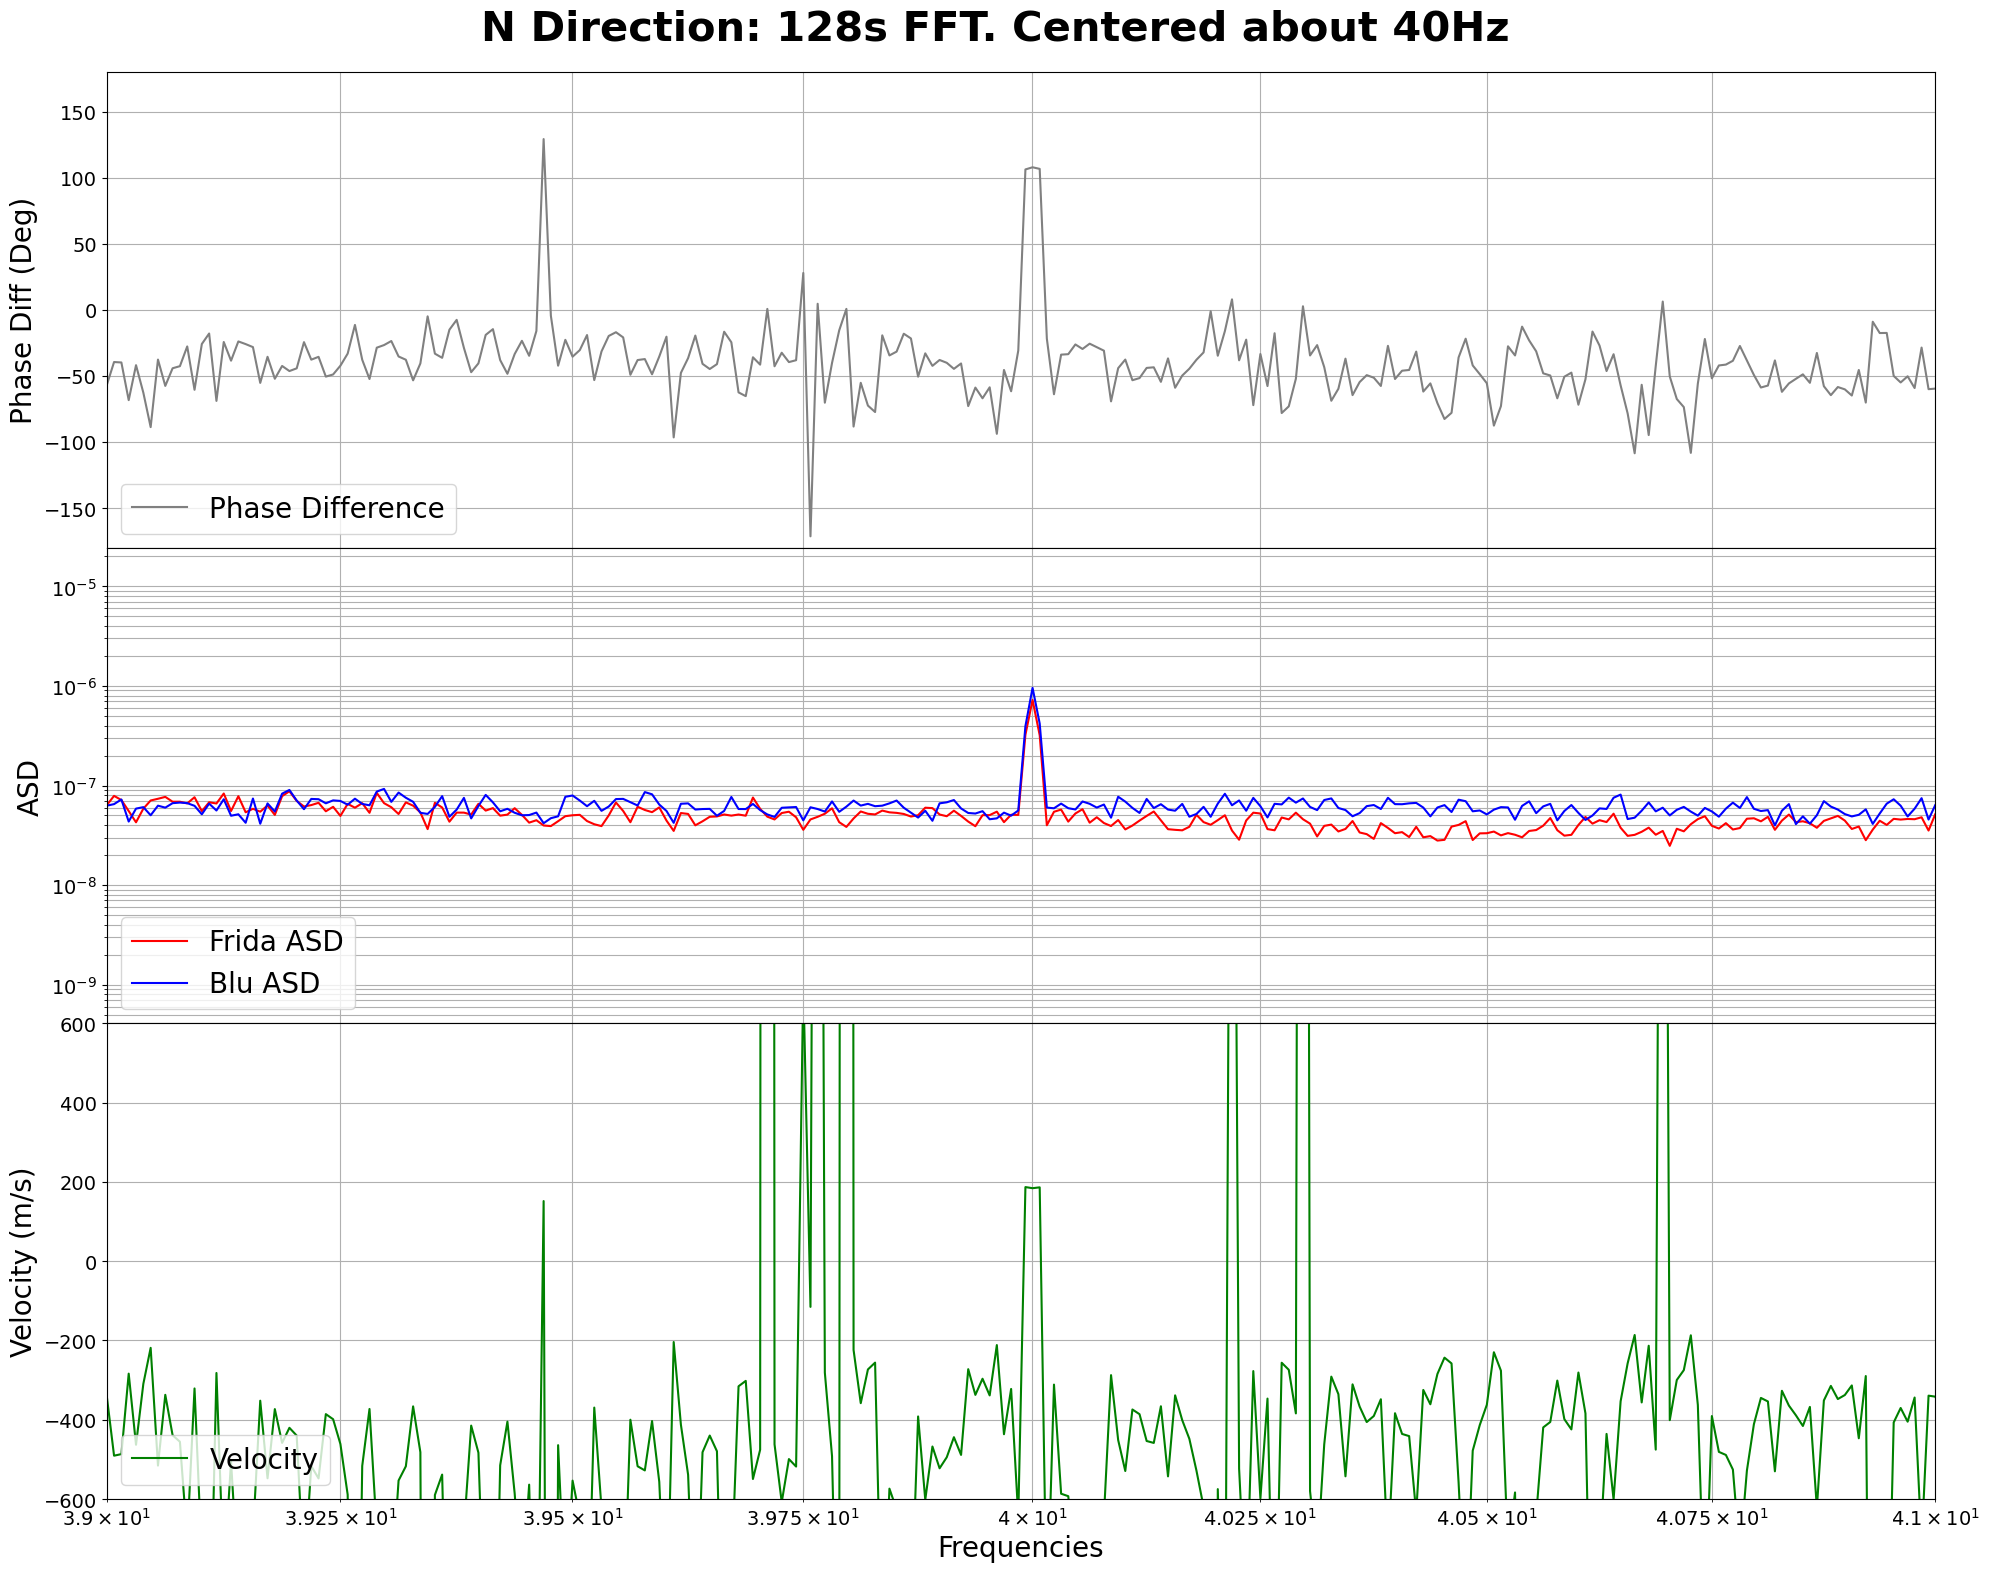

In [112]:
### --- Plot Selected Frequency --- ###

freq = 40 #Hz


fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(20, 16))
axs[0].set_xlim(freq-1,freq+1)
axs[0].set_xscale('log')


axs[0].plot(frequencies, phase_spectrum_deg, label='Phase Difference',color='gray')
axs[0].set_ylabel('Phase Diff (Deg)',fontsize=20)
axs[0].set_ylim(-180,180)
axs[0].legend(fontsize=20,loc = 'lower left')

axs[1].plot(freq1, F_N_asd, label="Frida ASD",color='red')
axs[1].plot(freq2, B_N_asd, label="Blu ASD",color='blue')
axs[1].set_ylabel('ASD',fontsize=20)
axs[1].set_yscale('log')
axs[1].legend(fontsize=20,loc = 'lower left')

axs[2].plot(frequencies, vel, label='Velocity',color='green')
axs[2].set_ylabel('Velocity (m/s)',fontsize=20)
axs[2].set_ylim(-600,600)
axs[2].set_xlabel('Frequencies',fontsize=20)  # Label only the bottom plot
axs[2].legend(fontsize=20,loc = 'lower left')


for ax in axs:
    ax.grid(True, which='both', ls='-')
    ax.tick_params(axis='both', which='both', labelsize=14)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fig.subplots_adjust(hspace=0)
fig.suptitle("N Direction: "+str(fft_window_s)+"s FFT. Centered about "+str(freq)+"Hz",fontsize = 30, fontweight='bold', y=0.98)
plt.show()

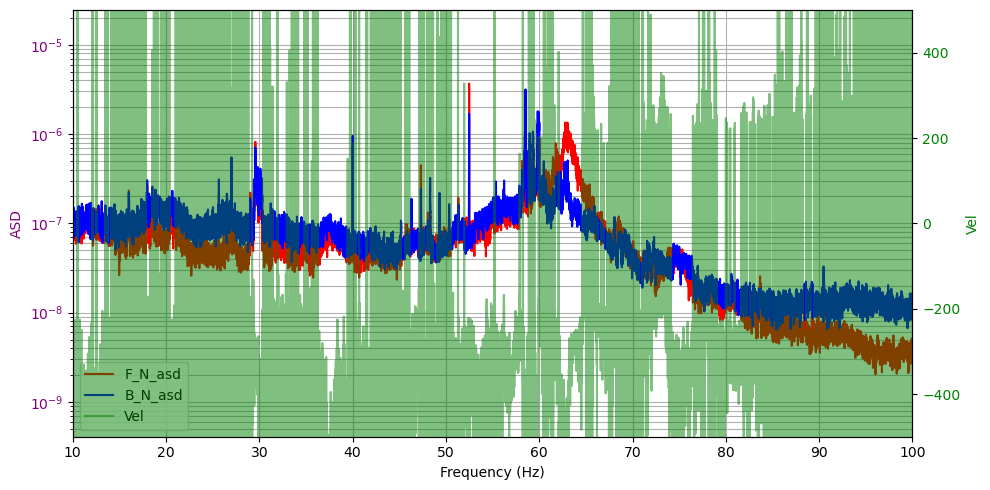

In [113]:
import matplotlib.pyplot as plt

#vibecoded display lol

# 1. Initialize the figure and the first axis (ASD - Left Y-axis)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Set shared X-axis limits and logarithmic scale
ax1.set_xlim(1e1, 1e2)
#ax1.set_xscale('log')

# Configure Left Y-axis (ASD - Logarithmic scale)
ax1.set_yscale('log')
ax1.set_ylabel('ASD', color='purple')
line1 = ax1.plot(freq1, F_N_asd, color='red', label='F_N_asd')
line2 = ax1.plot(freq2, B_N_asd, color='blue', label='B_N_asd')
ax1.tick_params(axis='y', labelcolor='purple')

# 2. Create the second axis sharing the X-axis (Phase - Right Y-axis)
ax2 = ax1.twinx()

# Configure Right Y-axis (Phase Difference - Linear scale)
ax2.set_ylim(-500, 500)
ax2.set_ylabel('Vel', color='green')
line3 = ax2.plot(frequencies, vel, color='green', label='Vel',alpha=0.5)
ax2.tick_params(axis='y', labelcolor='green')

# 3. Combine legends from both axes into one box
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower left')
ax1.grid(True, which='both', ls='-')

# 4. Final adjustments and display
ax1.set_xlabel('Frequency (Hz)')
fig.tight_layout()
plt.show()
